In [22]:
import torch

x_data = torch.tensor([[0, 0],
                       [0, 1],
                       [1, 0],
                       [1, 1]], dtype=torch.float32)  # float32 (não float)

y_data = torch.tensor([[0],
                       [1],
                       [1],
                       [0]], dtype=torch.float32)

#############################################################

class Model(torch.nn.Module):
  def __init__(self):
    super(Model, self).__init__()
    self.l1 = torch.nn.Linear(2,4)
    self.l2 = torch.nn.Linear(4,8)      # Aumentar de 3 para 8
    self.l3 = torch.nn.Linear(8,1)      # Input agora é 8 (não 3)
    self.Sigmoid = torch.nn.Sigmoid()
  def forward(self, x):
    sigma = self.Sigmoid
    out1 = sigma( self.l1(x) )
    out2 = sigma( self.l2(out1) )
    y_pred = sigma( self.l3(out2) )
    return y_pred
  def predict(self, x):
    with torch.no_grad():              # Adicionar no_grad()
      return (self.forward(x) > 0.5).int().item()  # .int().item()

#############################################################
model = Model()

criterion = torch.nn.BCELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Adam + lr=0.01

for epoch in range(500):
  y_pred = model(x_data)

  loss = criterion(y_pred, y_data)
  optimizer.zero_grad()

  loss.backward()
  optimizer.step()
  if epoch%50 == 0:
    print(f"Época {epoch} | Loss {loss.data}")

# Mostrar Tabela Verdade do XOR
print("\n" + "="*50)
print("TABELA VERDADE - XOR")
print("="*50)
print(f"{'x1':<5} {'x2':<5} {'Saída Esperada':<18} {'Predição':<12}")
print("-"*50)

for x, y in zip(x_data, y_data):
    x_input = x.unsqueeze(0)
    pred = model.predict(x_input)
    expected = int(y.item())
    print(f"{int(x[0]):<5} {int(x[1]):<5} {expected:<18} {pred:<12}")

print("="*50)

Época 0 | Loss 0.6995971202850342
Época 50 | Loss 0.6929430365562439
Época 100 | Loss 0.6866464018821716
Época 150 | Loss 0.4948391914367676
Época 200 | Loss 0.10601934790611267
Época 250 | Loss 0.029698681086301804
Época 300 | Loss 0.014430847950279713
Época 350 | Loss 0.008870691992342472
Época 400 | Loss 0.006141053047031164
Época 450 | Loss 0.004565289244055748

TABELA VERDADE - XOR
x1    x2    Saída Esperada     Predição    
--------------------------------------------------
0     0     0                  0           
0     1     1                  1           
1     0     1                  1           
1     1     0                  0           


Porta XOR

<img src="https://embarcados.com.br/wp-content/uploads/2015/11/xor-11-850x308.jpg.webp" width="50%">

Treinamento: XOR Neural Network (Sigmoid)
Época                 Loss        Acurácia
------------------------------------------
Época 0      | Loss      0.69646311 | Acurácia  50.00%
Época 50     | Loss      0.69276243 | Acurácia  50.00%
Época 100    | Loss      0.68280959 | Acurácia  75.00%
Época 150    | Loss      0.42080018 | Acurácia 100.00%
Época 200    | Loss      0.05101066 | Acurácia 100.00%
Época 250    | Loss      0.01481699 | Acurácia 100.00%
Época 300    | Loss      0.00781137 | Acurácia 100.00%
Época 350    | Loss      0.00506664 | Acurácia 100.00%
Época 400    | Loss      0.00363498 | Acurácia 100.00%
Época 450    | Loss      0.00277039 | Acurácia 100.00%
------------------------------------------

✓ Predições finais:
------------------------------------------
Input [0.0, 0.0] → Predito: 0, Real: 0 ✓
Input [0.0, 1.0] → Predito: 1, Real: 1 ✓
Input [1.0, 0.0] → Predito: 1, Real: 1 ✓
Input [1.0, 1.0] → Predito: 0, Real: 0 ✓
------------------------------------------


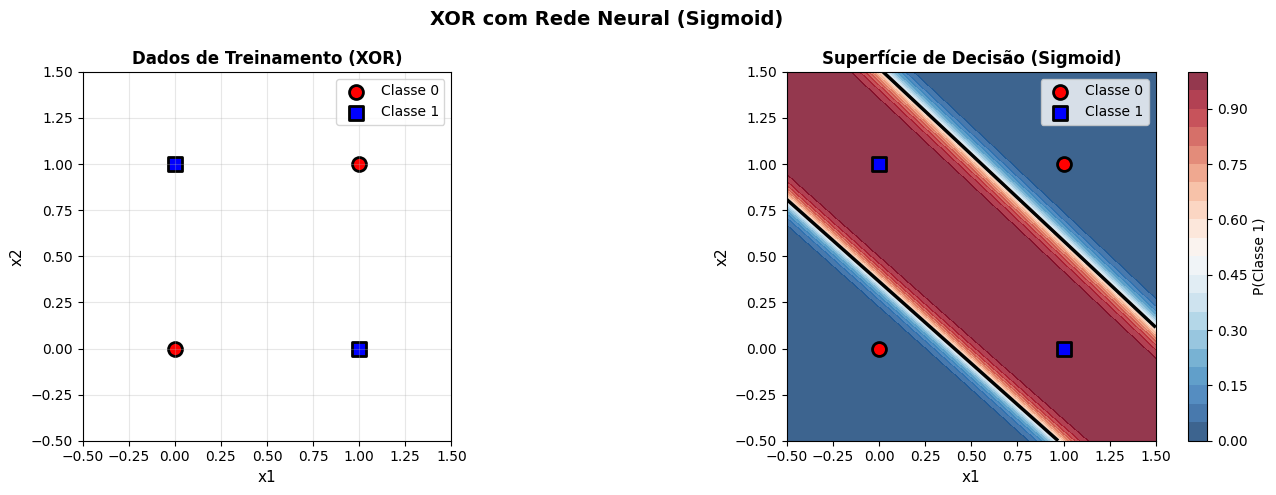

In [23]:
import torch
import matplotlib.pyplot as plt
import numpy as np

x_data = torch.tensor([[0, 0],
                       [0, 1],
                       [1, 0],
                       [1, 1]], dtype=torch.float32)

y_data = torch.tensor([[0],
                       [1],
                       [1],
                       [0]], dtype=torch.float32)

#############################################################

class Model(torch.nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.l1 = torch.nn.Linear(2, 4)      # Input: 2 → Hidden: 4
        self.l2 = torch.nn.Linear(4, 8)      # Hidden: 4 → Hidden: 8
        self.l3 = torch.nn.Linear(8, 1)      # Hidden: 8 → Output: 1
        self.sigmoid = torch.nn.Sigmoid()    # Usar Sigmoid em todas as camadas

    def forward(self, x):
        # Sigmoid em todas as camadas
        out1 = self.sigmoid(self.l1(x))
        out2 = self.sigmoid(self.l2(out1))
        y_pred = self.sigmoid(self.l3(out2))
        return y_pred

    def predict(self, x):
        with torch.no_grad():
            return (self.forward(x) > 0.5).int().item()

#############################################################

# Inicializar modelo
model = Model()

# Critério e otimizador
criterion = torch.nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

print("=" * 60)
print("Treinamento: XOR Neural Network (Sigmoid)")
print("=" * 60)
print(f"{'Época':<10} {'Loss':>15} {'Acurácia':>15}")
print("-" * 42)

for epoch in range(500):
    # Forward pass
    y_pred = model(x_data)

    # Calcular loss
    loss = criterion(y_pred, y_data)

    # Zerar gradientes
    optimizer.zero_grad()

    # Backward pass
    loss.backward()

    # Atualizar parâmetros
    optimizer.step()

    # Calcular acurácia
    if epoch % 50 == 0:
        with torch.no_grad():
            predictions = (model(x_data) > 0.5).float()
            accuracy = (predictions == y_data).float().mean().item()
            print(f"Época {epoch:<6} | Loss {loss.item():>15.8f} | Acurácia {accuracy*100:>6.2f}%")

print("-" * 42)

# Testar predições finais
print("\n✓ Predições finais:")
print("-" * 42)
for i, (x, y) in enumerate(zip(x_data, y_data)):
    pred = model.predict(x.unsqueeze(0))
    actual = int(y.item())
    status = "✓" if pred == actual else "✗"
    print(f"Input {x.tolist()} → Predito: {pred}, Real: {actual} {status}")

print("-" * 42)

# Visualizar a superfície de decisão (CORRIGIDO)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

# Painel 1: Pontos de treinamento
# Corrigir indexação: usar squeeze() para remover dimensão extra
y_flat = y_data.squeeze()

# Separar pontos por classe
indices_0 = (y_flat == 0)
indices_1 = (y_flat == 1)

axes[0].scatter(x_data[indices_0, 0], x_data[indices_0, 1],
               s=100, c='red', marker='o', label='Classe 0', edgecolors='black', lw=2)
axes[0].scatter(x_data[indices_1, 0], x_data[indices_1, 1],
               s=100, c='blue', marker='s', label='Classe 1', edgecolors='black', lw=2)
axes[0].set_xlim(-0.5, 1.5)
axes[0].set_ylim(-0.5, 1.5)
axes[0].set_xlabel('x1', fontsize=11)
axes[0].set_ylabel('x2', fontsize=11)
axes[0].set_title('Dados de Treinamento (XOR)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

# Painel 2: Superfície de decisão
x1 = np.linspace(-0.5, 1.5, 100)
x2 = np.linspace(-0.5, 1.5, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = np.zeros_like(X1)

with torch.no_grad():
    for i in range(X1.shape[0]):
        for j in range(X1.shape[1]):
            x = torch.tensor([[X1[i, j], X2[i, j]]], dtype=torch.float32)
            Z[i, j] = model.forward(x).item()

contour = axes[1].contourf(X1, X2, Z, levels=20, cmap='RdBu_r', alpha=0.8)
axes[1].contour(X1, X2, Z, levels=[0.5], colors='black', linewidths=2.5)

# Plotar pontos de treinamento
axes[1].scatter(x_data[indices_0, 0], x_data[indices_0, 1],
               s=100, c='red', marker='o', label='Classe 0', edgecolors='black', lw=2, zorder=5)
axes[1].scatter(x_data[indices_1, 0], x_data[indices_1, 1],
               s=100, c='blue', marker='s', label='Classe 1', edgecolors='black', lw=2, zorder=5)

axes[1].set_xlim(-0.5, 1.5)
axes[1].set_ylim(-0.5, 1.5)
axes[1].set_xlabel('x1', fontsize=11)
axes[1].set_ylabel('x2', fontsize=11)
axes[1].set_title('Superfície de Decisão (Sigmoid)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10, loc='upper right')
axes[1].set_aspect('equal')
cbar = plt.colorbar(contour, ax=axes[1], label='P(Classe 1)')

plt.suptitle('XOR com Rede Neural (Sigmoid)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()